# Synthetic SaaS Subscription Dataset – Exploratory Analysis

This notebook explores a synthetic SaaS subscription dataset designed to simulate a real subscription-based software business.

The dataset includes customer accounts, subscription plans, invoices, payments, churn events, and plan upgrades.

The purpose of this notebook is to demonstrate how analysts can explore SaaS business data and understand common subscription metrics.

Key topics explored in this notebook:

• Dataset overview  
• Subscription activity  
• Plan distribution  
• Customer churn  

Tools used:

- Python
- Pandas
- Matplotlib

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## Importing Required Libraries

We import the necessary Python libraries used for data manipulation, analysis, and visualization.

In [2]:
import os

os.listdir('/kaggle/input/datasets/ansarimuzammil/synthetic-saas-subscription-dataset')

['invoices.csv',
 'subscriptions.csv',
 'Churn_events.csv',
 'customers.csv',
 'plan_chnages.csv',
 'payments.csv',
 'subscription_plans.csv']

## Dataset Overview

This synthetic dataset simulates a SaaS subscription business.

Tables included:

- customers – user signup information  
- subscriptions – subscription lifecycle data  
- subscription_plans – available pricing tiers  
- invoices – billing records  
- payments – payment transactions  
- churn_events – subscription cancellations  
- plan_changes – upgrades and downgrades between plans

In [3]:
base_path = "/kaggle/input/datasets/ansarimuzammil/synthetic-saas-subscription-dataset/"

customers = pd.read_csv(base_path + "customers.csv")
subscriptions = pd.read_csv(base_path + "subscriptions.csv")
plans = pd.read_csv(base_path + "subscription_plans.csv")
payments = pd.read_csv(base_path + "payments.csv")
invoices = pd.read_csv(base_path + "invoices.csv")
churn = pd.read_csv(base_path + "Churn_events.csv")
plan_changes = pd.read_csv(base_path + "plan_chnages.csv")

## 2. Dataset Preview

Before performing analysis, we inspect the structure of the dataset to understand the available columns and fields.

In [4]:
customers.head()

,1,2023-05-11,medium,finance,referral,Germany
0,2,2023-04-25,large,health,referral,US
1,3,2023-03-18,large,retail,organic,Germany
2,4,2023-05-08,large,retail,ads,UK
3,5,2023-05-28,small,retail,organic,Germany
4,6,2023-04-16,small,retail,ads,US


In [5]:
subscriptions.head()

,1,1.1,2023-05-11,Unnamed: 3,active,5
0,3,3,2023-03-18,NaN,active,1
1,9,9,2023-10-13,NaN,active,6
2,15,15,2023-07-19,NaN,active,1
3,17,17,2023-04-29,NaN,active,2
4,18,18,2023-06-23,NaN,active,4


In [6]:
plans.head()

,1,Free,monthly,0.00
0,2,Basic,monthly,19.0
1,3,Pro,monthly,49.0
2,4,Premium,monthly,99.0
3,5,Basic,annual,190.0
4,6,Pro,annual,490.0


## 3. Dataset Size

Understanding the number of records in each table helps evaluate the scale of the dataset.

In [7]:
print("Customers:", customers.shape)
print("Subscriptions:", subscriptions.shape)
print("Plans:", plans.shape)
print("Invoices:", invoices.shape)
print("Payments:", payments.shape)
print("Churn Events:", churn.shape)
print("Plan Changes:", plan_changes.shape)

Customers: (24999, 6)
Subscriptions: (24999, 6)
Plans: (6, 4)
Invoices: (68410, 6)
Payments: (68410, 6)
Churn Events: (9756, 4)
Plan Changes: (786, 5)


## 4. Subscription Plan Distribution

Next we examine how subscriptions are distributed across different pricing plans.

Understanding plan distribution helps identify which pricing tiers are most commonly used.

In [8]:
subscriptions.columns

Index(['1', '1.1', '2023-05-11', 'Unnamed: 3', 'active', '5'], dtype='object')

In [9]:
subscriptions = pd.read_csv(
    base_path + "subscriptions.csv",
    header=None,
    names=[
        "subscription_id",
        "customer_id",
        "subscription_start",
        "subscription_end",
        "status",
        "plan_id"
    ]
)

In [10]:
subscriptions.head()

,subscription_id,customer_id,subscription_start,subscription_end,status,plan_id
0,1,1,2023-05-11,NaN,active,5
1,3,3,2023-03-18,NaN,active,1
2,9,9,2023-10-13,NaN,active,6
3,15,15,2023-07-19,NaN,active,1
4,17,17,2023-04-29,NaN,active,2


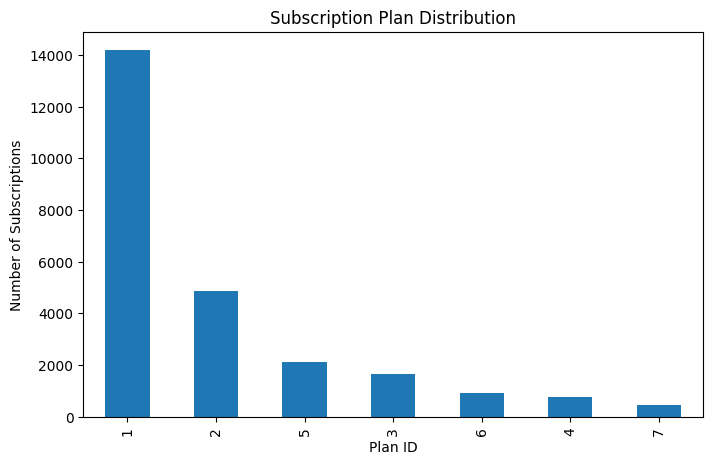

In [11]:
subscriptions['plan_id'].value_counts().plot(kind='bar', figsize=(8,5))

plt.title("Subscription Plan Distribution")
plt.xlabel("Plan ID")
plt.ylabel("Number of Subscriptions")

plt.show()

## 5. Monthly Revenue Trend

Invoices represent billing events in the SaaS platform.  
We aggregate invoice amounts over time to understand revenue trends.

In [12]:
invoices = pd.read_csv(
    base_path + "invoices.csv",
    header=None,
    names=[
        "invoice_id",
        "subscription_id",
        "billing_period_start",
        "billing_period_end",
        "invoice_amount",
        "invoice_status"
    ]
)

In [13]:
invoices.head()

,invoice_id,subscription_id,billing_period_start,billing_period_end,invoice_amount,invoice_status
0,1,1,2023-05-11,2024-05-11,190.0,paid
1,2,1,2024-05-11,2025-05-11,190.0,paid
2,3,9,2023-10-13,2024-10-13,490.0,paid
3,4,9,2024-10-13,2025-10-13,490.0,paid
4,5,10,2023-01-31,2023-02-28,99.0,paid


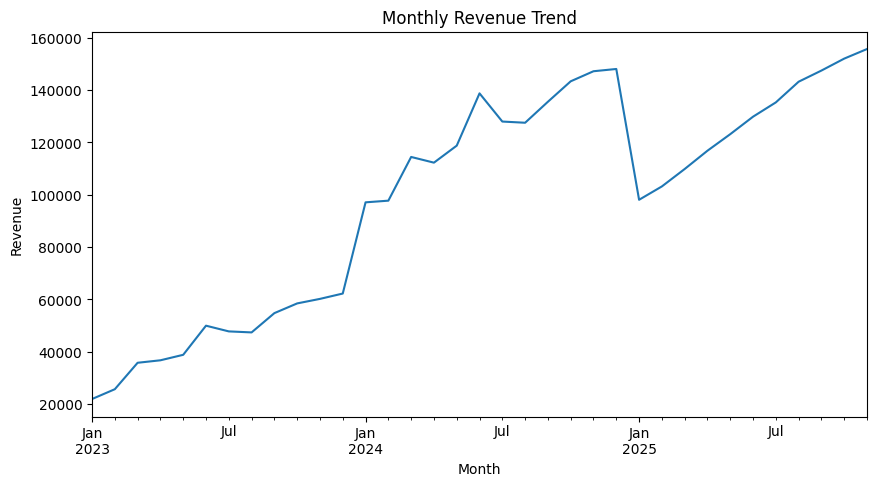

In [14]:
invoices['billing_period_start'] = pd.to_datetime(invoices['billing_period_start'])

monthly_revenue = invoices.groupby(
    invoices['billing_period_start'].dt.to_period('M')
)['invoice_amount'].sum()

monthly_revenue.plot(figsize=(10,5))

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

## 6. Customer Churn

Customer churn represents subscriptions that were cancelled.

Understanding churn behavior is critical for subscription businesses because it directly affects recurring revenue.

In [15]:
churn = pd.read_csv(
    base_path + "Churn_events.csv",
    header=None,
    names=[
        "churn_id",
        "subscription_id",
        "churn_date",
        "churn_reason"
    ]
)

In [16]:
churn.head()

,churn_id,subscription_id,churn_date,churn_reason
0,1,2,2023-11-25,other
1,2,4,2023-10-08,price
2,3,5,2023-11-28,budget
3,4,6,2024-01-16,product_fit
4,5,7,2025-01-16,other


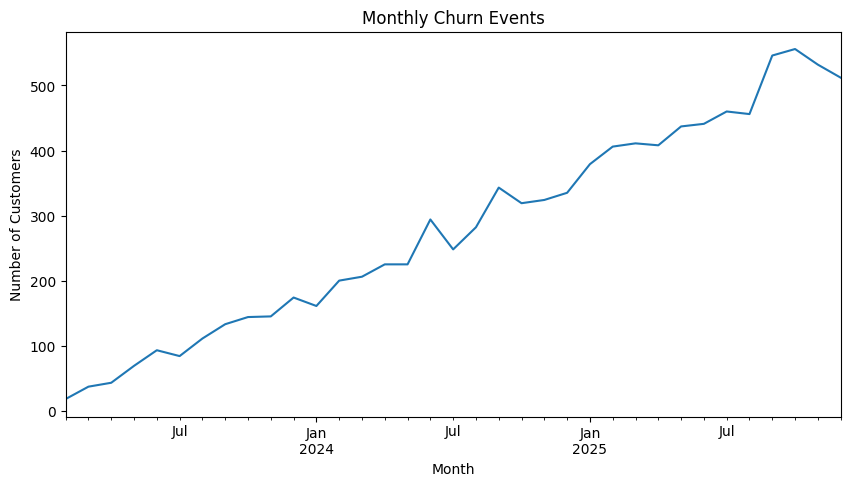

In [17]:
churn['churn_date'] = pd.to_datetime(churn['churn_date'])

monthly_churn = churn.groupby(
    churn['churn_date'].dt.to_period('M')
).size()

monthly_churn.plot(figsize=(10,5))

plt.title("Monthly Churn Events")
plt.xlabel("Month")
plt.ylabel("Number of Customers")

plt.show()

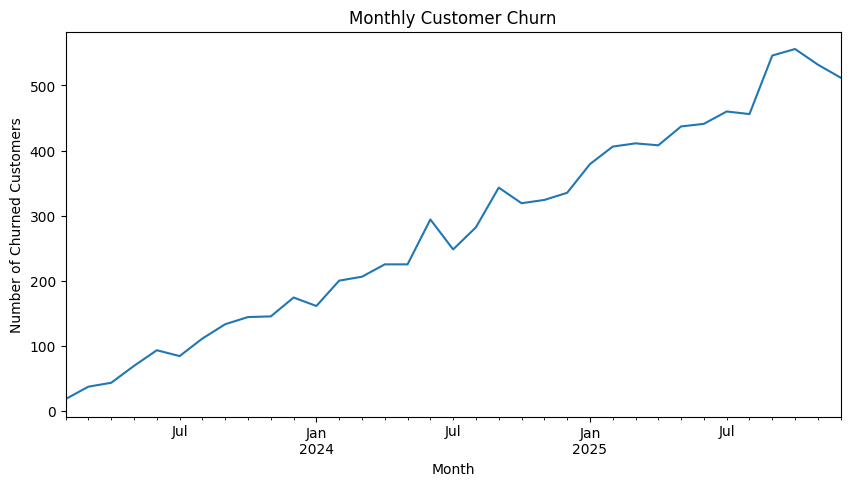

In [18]:
churn['churn_date'] = pd.to_datetime(churn['churn_date'])

monthly_churn = churn.groupby(
    churn['churn_date'].dt.to_period('M')
).size()

monthly_churn.plot(figsize=(10,5))

plt.title("Monthly Customer Churn")
plt.xlabel("Month")
plt.ylabel("Number of Churned Customers")

plt.show()

## 7. Dataset Structure

The dataset represents a simplified SaaS database with relational tables.

Key relationships include:

Customers → Subscriptions  
Subscriptions → Invoices  
Subscriptions → Churn Events  
Subscriptions → Plan Changes  

This structure allows analysts to study customer lifecycle behavior and subscription revenue.